In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense as ham
from quant_rotor.Hamiltonian_models.Dense.heisenberg_operators import heisenberg_operators
from quant_rotor.Hamiltonian_models.Dense.rotor_operators import rotor_operators

from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
import quant_rotor.CCC_integration_methods.Dense.thermofield_boltz_funcs as bz

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat


In [2]:
np.set_printoptions(precision=10)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

# Initialization Primitive Rotor

In [35]:
state = 3
state_2 = state**2
site = 3

p = state
i = 1
a = p - i

g = 0.6
periodic = False

beta = 10

In [36]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, V, periodic)

In [37]:
np.exp(-(np.diag(K) * beta) / 2)

array([1.         +0.j, 0.006737947+0.j, 0.006737947+0.j])

In [38]:
eig_val, eig_vec = np.linalg.eigh(H)

In [39]:
U, _, U_vec = bz.thermofield_change_of_basis_new(K, beta)

# U, Q= bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_tilda = U.T @ K_prim @ U

V_tensor = V.reshape(state, state, state, state)

V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

In [40]:
U_reshaped = U.reshape(state, state, state_2)

In [41]:
V_vec = np.exp((np.diag(K) * beta) / 2)

In [42]:
V_vec

array([  1.          +0.j, 148.4131591026+0.j, 148.4131591026+0.j])

In [43]:
p = state_2
i = 1
a = p - i

In [44]:
t_a_i_tensor = np.full((site, a, i), 0.0, dtype=complex)
t_ab_ij_tensor = np.full((site, site, a, a, i, i), 0.0, dtype=complex)

In [45]:
V_0 = 0
V_p = np.zeros((state_2))

In [46]:
for i in range(site):
    V_0 = np.einsum("m, mMP -> P", V_vec,  U_reshaped).reshape(state_2, 1)[0, 0]
    t_a_i_tensor[i] = np.einsum("m, mMP -> P", V_vec,  U_reshaped).reshape(state_2, 1)[1:, :]
    V_p = np.einsum("m, mMP -> P", V_vec,  U_reshaped).reshape(state_2, 1)

In [47]:
t_a_i_tensor = t_a_i_tensor / V_0

In [48]:
time_TF, energy_TD_TF_CCC, one_max_TD_TF_CC, two_max_TD_TF_CC = integration_scheme(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, t_init=0, t_final=10, nof_points=10000, import_guess=True, t_0_import=V_0, t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

In [49]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])

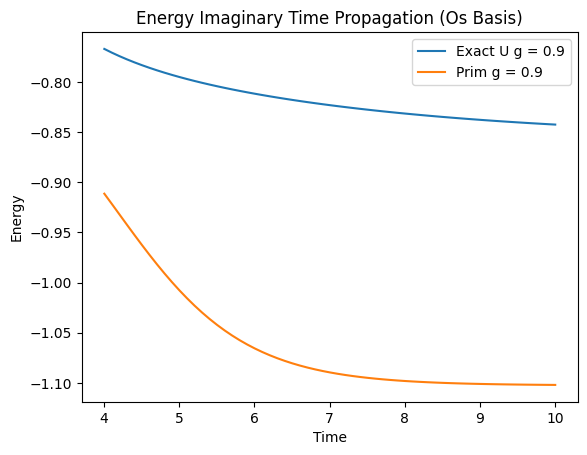

TF (-1.1020487415158138+0j)
Exact:  -0.8426081902972462


In [34]:
plt.plot(time_TF[time_TF> 4], ED_U_val[time_TF> 4], label=f"Exact U g = {g}")
plt.plot(time_TF[time_TF> 4], energy_TD_TF_CCC[time_TF> 4], label=f"Prim g = {g}")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TD_TF_CCC[-1])
print("Exact: ", ED_U_val[-1])

In [5]:
U, vec= bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_prim = np.einsum('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_tilda = U.T @ K_prim @ U

V_tensor = V.reshape(state, state, state, state)

V_prim = np.einsum('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_prim.reshape(state**2, state**2, state**2, state**2)

V_tilda = np.einsum('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

[0.4472135955 0.4472135955 0.4472135955 0.4472135955 0.4472135955]
[-0.2 -0.2 -0.2 -0.2 -0.2]
[-0.2 -0.2 -0.2 -0.2 -0.2]
[-0.2 -0.2 -0.2 -0.2 -0.2]
[-0.2 -0.2 -0.2 -0.2 -0.2]
[-0.2 -0.2 -0.2 -0.2 -0.2]
[1. 1. 1. 1.]


In [16]:
B = np.array([-0.2, -0.2, 0.8 ,-0.2 ,-0.2])
B_1 = np.array([-0.2, -0.2, -0.2 ,-0.2, 0.8])

In [ ]:
B @ B_1

np.float64(-0.2)

In [21]:
vec

array([[ 0.4472135955,  0.4171584925,  0.7902003232,  0.          ,  0.0395251996],
       [ 0.4472135955,  0.0714445581, -0.2494025417, -0.2171575338, -0.8279714082],
       [ 0.4472135955,  0.5115508701, -0.5470521666, -0.1039630748,  0.4777460763],
       [ 0.4472135955, -0.6718853449,  0.0870801254, -0.5067009121,  0.2902435541],
       [ 0.4472135955, -0.3282685758, -0.0808257403,  0.8278215208,  0.0204565782]])

In [20]:
A=-vec + np.array([0,1,0,0,0])

In [21]:
1/np.sqrt(A @ A)

np.float64(0.9510565162951536)

In [22]:
1/np.sqrt(state)

np.float64(0.4472135954999579)

In [6]:
U.T @ U

array([[ 1.,  0., -0., -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-0., -0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,

In [25]:
time_TF_old, energy_TD_TF_CCC_old, one_max_TD_TF_CC_old, two_max_TD_TF_CC_old = integration_scheme(site, state_2, K_tilda, V_tilda.reshape(state_2, state_2, state_2, state_2), V_tilda.reshape(state_2, state_2, state_2, state_2), periodic=periodic, t_init=0, t_final=10, nof_points=10000)

In [27]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF_old])

In [ ]:
time_TF_old[ time_TF_old > 6]

array([0.   , 0.001, 0.011, 0.111, 0.211, 0.311, 0.411, 0.511, 0.611, 0.711, 0.811, 0.911, 1.011, 1.111, 1.211, 1.311, 1.411, 1.511, 1.611, 1.711, 1.811, 1.911, 2.011, 2.111, 2.211, 2.311, 2.411, 2.511, 2.611, 2.711, 2.811, 2.911])

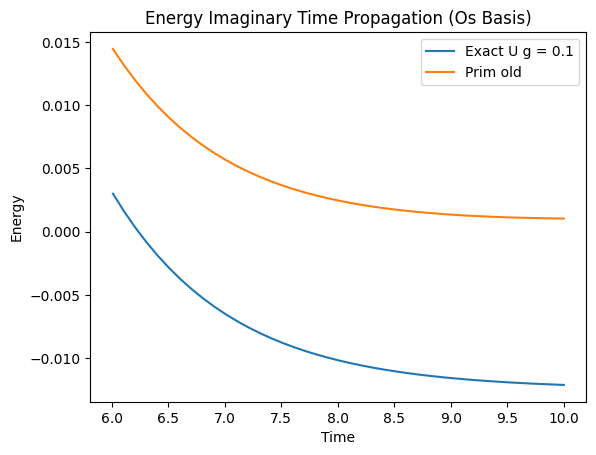

TF (0.0010291989438636281+0j)
Exact:  -0.012127832537906134


In [34]:
plt.plot(time_TF_old[ time_TF_old > 6], ED_U_val[ time_TF_old > 6], label=f"Exact U g = {g}")
# plt.plot(time_TF, energy_TD_TF_CCC, label=f"Prim")
plt.plot(time_TF_old[ time_TF_old > 6], energy_TD_TF_CCC_old[ time_TF_old > 6], label=f"Prim old")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("TF", energy_TD_TF_CCC_old[-1])
print("Exact: ", ED_U_val[-1])

In [37]:
energy_TD_TF_CCC_old[-1] + ED_U_val[-1]

np.complex128(-0.011098633594042506+0j)